In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import norm
from MSMsource_Gabriel import *

In [3]:
# Step 1: Load the CSV data

print("Loading the data from CSV...")
df = pd.read_csv("BTC-USD.csv", parse_dates=["Date"], index_col="Date")
start_date = '2024-01-01'
end_date = '2024-12-31'

# Convert to datetime

end_date = pd.to_datetime(end_date)
start_date = pd.to_datetime(start_date)
df_train = df.loc[start_date:end_date - pd.Timedelta(days=15)]
debut_prediction_date = df.loc["2025-01-01", " Price"]
df = df.loc[start_date:end_date] # Filter data between start_date and end_date
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespaces from column names
df_train.columns = df_train.columns.str.strip()
print("Data loaded and filtered between dates:", start_date, "and", end_date)

# Step 2: Calculate the daily log returns

print("Calculating the daily log returns...")
df['Log_Ret'] = np.log(df['Price'] / df['Price'].shift(1))
df_train['Log_Ret'] = np.log(df_train['Price'] / df_train['Price'].shift(1))
print("Log returns calculated.")

Loading the data from CSV...
Data loaded and filtered between dates: 2024-01-01 00:00:00 and 2024-12-31 00:00:00
Calculating the daily log returns...
Log returns calculated.


In [4]:
# parameters MSM

print("Step 6: Estimating parameters for the MSM...")
niter = 1
temperature = 1.0
stepsize = 1.0
k_bar = 4
data = df_train['Log_Ret'].values[:, np.newaxis]
data = data[1:]
#print(data)
parameters, LL, niter, output = glo_min(k_bar, data, niter, temperature, stepsize)
print(LL)
# name parameters for later use:
b = parameters[0]
m_0 = parameters[1]
gamma_kbar = parameters[2]
sigma = parameters[3]

pi_t = g_pi_t(m_0,k_bar,data,[b, gamma_kbar, sigma])[-1,:]
A = g_t(k_bar, b, gamma_kbar)

print("Parameters from glo_min for Simulated dataset: ", "\n"
      "kbar = ", k_bar,"\n"
      'b = %.5f' % b,"\n"
      'm_0 = %.5f' % m_0,"\n"
      'gamma_kbar = %.5f' % gamma_kbar,"\n"
      'sigma = %.5f' % sigma,"\n")

Step 6: Estimating parameters for the MSM...
-776.1551470018114
Parameters from glo_min for Simulated dataset:  
kbar =  4 
b = 1.49888 
m_0 = 1.43139 
gamma_kbar = 0.96490 
sigma = 0.02784 



In [ ]:
# compute MSM f

def compute_state_vols(m0, k_bar, sigma):
        m1 = 2-m0
        """Computes the volatility values for each of the 2**k_bar states in the MSM."""
        states = np.array([m0**(k_bar - np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int))) *
                        m1**(np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int)))
                        for i in range(2**k_bar)])
        states = sigma*np.sqrt(states)
        return states


# return the probabilities of the volatilities 

def msm_volatilite_instantanee(pi_t, m0, k_bar, sigma):
        """retourne un array de taille pi_t"""
        state_vols = compute_state_vols(m0, k_bar, sigma)
        return np.sqrt(np.dot(pi_t, state_vols**2))


# simulate price paths

def simulate_paths(simulations, price):
    "transforme log return en prix"
    N, T = simulations.shape
    simulations_path = np.zeros((N, T + 1))  # Include initial price in paths

    for i in range(N):  # Iterate over simulations
        logret = simulations[i, :]  # Select row i
        path = np.zeros(T + 1)
        path[0] = price  # Set initial price
        for t in range(1, T + 1):  # Start from 1
            path[t] = path[t - 1] * np.exp(logret[t - 1])  # Apply geometric return formula
        simulations_path[i, :] = path  # Store full path
    # print("path")
    # print(simulations_path[:, 1])  # Second column, first step after initial price
    return simulations_path


# simulate a lot of price paths

def monte_carlo_markov(N, T, A, pi_t, m0, k_bar, sigma):
    variance_vect = compute_state_vols(m0, k_bar, sigma)
    #simuler msm à partir de pi_t
    num_states = len(pi_t)
    simulations = np.zeros((N, T))  
    sigma_array = np.zeros((N, T)) 
    stationary_dist = np.linalg.matrix_power(A, 1000)[0]
    for i in range(N):
        state = np.random.choice(num_states, p=pi_t)  # Start from initial distribution

        for t in range(T):
            sigma = variance_vect[state]
            simulations[i, t] = np.random.normal(scale = sigma)
            sigma_array[i, t] = sigma
            state = np.random.choice(num_states, p=A[state, :])
    # print("simu")
    # print(simulations)
    return(simulations, sigma_array)



# parameters of predictions

N = 10000
T = 30

simulation_lr,volatilite_mat = monte_carlo_markov(N,T+1,A,pi_t,m_0,k_bar,sigma)
price = debut_prediction_date
simulation_p = simulate_paths(simulation_lr,price)
simulation_vol = np.std(simulation_lr, axis = 0)
volatilite_arr = np.mean(volatilite_mat, axis = 0)


#diff = simulation_vol - volatilite_arr
#print("Décalage moyen :", np.mean(diff))

[0.02618603 0.02773533 0.02743354 0.02784205 0.02790838 0.02771028
 0.02806968 0.02806771 0.02761583 0.028164   0.02786843 0.0277437
 0.02749878 0.02742191 0.02815144 0.02796365 0.02792976 0.02780783
 0.02750865 0.02807862 0.02779517 0.02744493 0.02811275 0.02777164
 0.02770802 0.02773064 0.02755887 0.02804411 0.02803164 0.02815586
 0.02782263]
94419.76
94962.833886396
96704.2599316106
98033.09244706787
106790.5474861764
103819.26300777722
101652.69997603408
101735.52742128719
99369.99771222682
99231.58038300242
101495.44696308489
100845.26748348365
100976.114166954
102284.14849046823
94490.00691519472
96844.18503396379
95468.872264086
96540.0281585256
94276.40497070945
99291.35515537593
98716.97443449283
101530.85259086589
99885.06833428258
101862.12150305505
101734.40210576373
104455.33037875209
108714.08216889884
108897.4000124016
106535.44222746775
105775.98362776324
106611.87331771677
109601.06809451694


In [ ]:
from tabulate import tabulate

def display_sample_logreturns(log_returns, num_paths=25, filename="logreturns_sample.pdf"):
    """
    log_returns : ndarray (N x T), N traj., T jours
    num_paths : nombre de trajectoires à afficher 
    """
    N, T = log_returns.shape
    if num_paths > N:
        raise ValueError("num_paths > N")
    
    # Sélection aléatoire des trajectoires

    indices = np.random.choice(N, size=num_paths, replace=False)
    selected = log_returns[indices, :]

    jours_selectionnes = [0, 1, 2, T//2 - 1, T//2, T//2 + 1, T-3, T-2, T-1]
    selected_days = np.array(jours_selectionnes)
    
    fig, ax = plt.subplots(figsize=(T * 0.25, num_paths * 0.4))
    

    # Création tableau de texte

    table_data = [[f"{selected[i, j]:.3f}" for j in selected_days] for i in range(num_paths)]
    table = ax.table(cellText=table_data,
                     colLabels=[f"J{j+1}" for j in selected_days],
                     loc='center', cellLoc='center')
    
    table.scale(0.3, 3)

    ax.axis('off')
    

    
    for key, cell in table.get_celld().items():
        cell.set_linewidth(0) 
        cell.set_edgecolor('white')  
        if key[0] == 0:  
            cell.get_text().set_weight('bold')
            cell.set_facecolor("#f5f5f5") 
        else:
            cell.set_facecolor('#eaeaea' if key[0] % 2 == 0 else 'white')

    for col in range(1, len(selected_days)):
        ax.axvline(x=col / len(selected_days), color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig(filename, format='pdf')
    plt.show()


simulated_log_returns = simulation_lr
latex_table = tabulate(simulated_log_returns, tablefmt="latex_booktabs")


In [8]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

csv_path = "BTC-USD.csv"
date_col = "Date"
price_col = " Price"
end_date = "2024-12-31"
T = 31
predictions = simulation_p

def get_true_prices_after_training(csv_path, date_col, price_col, end_date, T):
    # Charger le CSV
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)

    # Trouver les T jours après end_date
    mask = df[date_col] > pd.to_datetime(end_date)
    future_prices = df.loc[mask, price_col].head(T).values

    return future_prices

true_prices = get_true_prices_after_training(csv_path, date_col, price_col, end_date, T)
print(true_prices)      



# --- CALCUL DES ERREURS ---
def evaluate_predictions(predictions, true_prices):
    mae_list = []
    rmse_list = []

    for i in range(predictions.shape[0]):
        pred = predictions[i]
        mae_list.append(mean_absolute_error(true_prices, pred))
        rmse_list.append(np.sqrt(mean_squared_error(true_prices, pred)))

    maes = np.array(mae_list)
    rmses = np.array(rmse_list)

    mean_pred = predictions.mean(axis=0)
    mae_mean = mean_absolute_error(true_prices, mean_pred)
    rmse_mean = np.sqrt(mean_squared_error(true_prices, mean_pred))

    return maes, rmses, mean_pred, mae_mean, rmse_mean

# tabs and graphics
def plot_results(true_prices, mean_pred, predictions, maes, rmses):
    T = len(true_prices)
    x = np.arange(T)

    plt.figure(figsize=(10, 5))
    plt.plot(x, true_prices, label="Prix réels", linewidth=2)
    plt.plot(x,np.percentile(predictions, 10, axis=0), color="green", alpha=1, label="VaR 90%")
    plt.plot(x,np.percentile(predictions, 90, axis=0), color="green", alpha=1)
    plt.plot(x,np.percentile(predictions, 5, axis=0), color="orange", alpha=1, label="VaR 95%")
    plt.plot(x,np.percentile(predictions, 95, axis=0), color="orange", alpha=1)
    plt.plot(x,np.percentile(predictions, 1, axis=0), color="red", alpha=1, label="VaR 99%")
    plt.plot(x,np.percentile(predictions, 99, axis=0), color="red", alpha=1)


    plt.title("Prix réels vs Var")
    plt.xlabel("Jour")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    for metric, values in zip(["MAE", "RMSE"], [maes, rmses]):
        plt.figure(figsize=(8, 4))
        sns.histplot(values, kde=True, bins=50)
        plt.axvline(values.mean(), color='r', linestyle='--', label=f"Moyenne: {values.mean():.2f}")
        plt.title(f"Distribution des {metric}")
        plt.xlabel(metric)
        plt.ylabel("Nombre de prédictions")
        plt.legend()
        plt.tight_layout()
        plt.show()

    df_metrics = pd.DataFrame({
        "MAE": maes,
        "RMSE": rmses
    })
    print("\n📊 Statistiques descriptives des erreurs :\n")
    print(df_metrics.describe())

if __name__ == "__main__":

    maes, rmses, mean_pred, mae_mean, rmse_mean = evaluate_predictions(predictions, true_prices)

    print(f"\n✅ MAE (moyenne des prédictions): {mae_mean:.2f}")
    print(f"✅ RMSE (moyenne des prédictions): {rmse_mean:.2f}")

    plot_results(true_prices, mean_pred, predictions, maes, rmses)

[ 94419.76  96886.88  98107.43  98236.23  98314.96 102078.09  96922.7
  95043.52  92484.04  94701.45  94566.59  94488.44  94516.52  96534.05
 100504.49  99756.91 104462.04 104408.07 101089.61 102016.66 106146.27
 103653.07 103960.17 104819.48 104714.65 102682.5  102087.69 101332.48
 103703.21 104735.3  102405.02]


ValueError: Found input variables with inconsistent numbers of samples: [31, 32]

In [11]:
# Calculate MAE and RMSE

def calculate_mae(true_vol, forecast_vol):
    return np.mean(np.abs(true_vol - forecast_vol))


data_real = df_train['Log_Ret'].values[:, np.newaxis]
data_real = data_real[1:]
data = df['Log_Ret'].values[:, np.newaxis]
data = data[1:]

msm_fit_volatility = compute_MSM_vol(data_real, parameters, k_bar)[0]
msm_fit_volatility_tot = compute_MSM_vol(data, parameters, k_bar)[0]

def historical_volatility(logret, window=30):
    return logret.rolling(window=window).std()

historical_vol = historical_volatility(df['Log_Ret'], 30)
def ewma_volatility(returns, span=30):
    return returns.ewm(span=span).std() 

# Set the lambda value for the EWMA model 
lambda_ewma = 0.94

# Calculate the EWMA volatility (standard deviation)
ewma_vol = df['Log_Ret'].ewm(span=(2 / (1 - lambda_ewma)), adjust=False).std()  



In [12]:
garch_model = arch_model(data, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')

# Forecast T steps ahead

garch_forecast = garch_fit.forecast(horizon=T)

# Extract conditional volatility forecasts

garch_vol_forecast = np.sqrt(garch_forecast.variance.values[-1])  # shape: (T,)

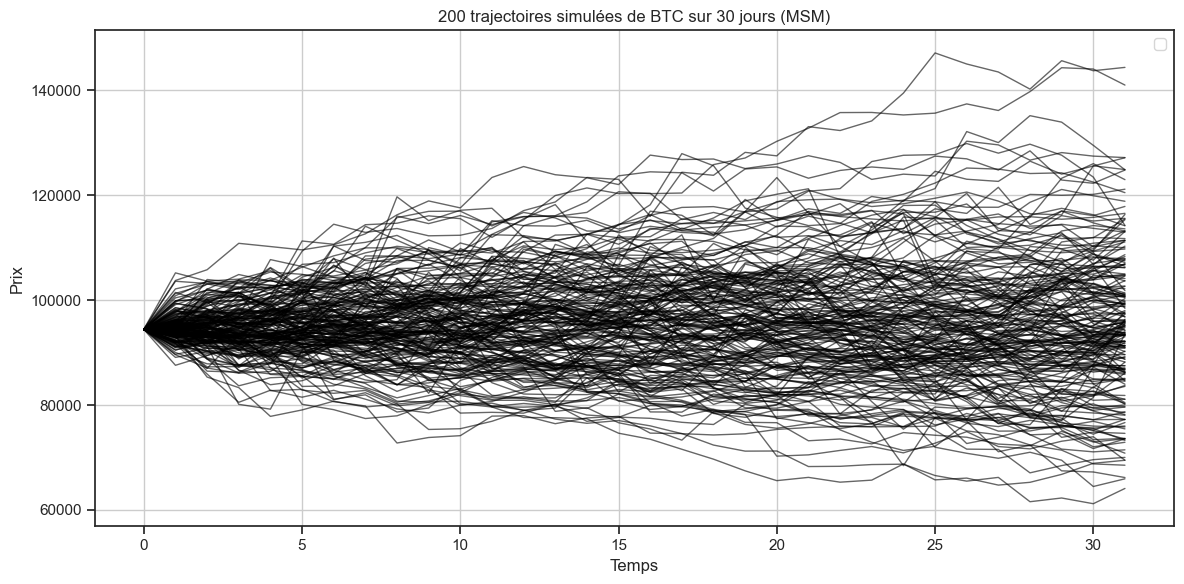

In [13]:
def compute_var(price_paths, percentile=5):
    return np.percentile(price_paths, percentile, axis=0)

def plot_paths_with_var(price_paths, var_path, num_paths_to_plot=200, percentile=5):
    T_plus_1 = price_paths.shape[1]
    time = np.arange(T_plus_1)

    # Choose 20 trajectories 

    selected_indices = np.random.choice(price_paths.shape[0], num_paths_to_plot, replace=False)
    selected_paths = price_paths[selected_indices]

    plt.figure(figsize=(12, 6))
    for path in selected_paths:
        plt.plot(time, path, color = 'black', alpha=0.6, linewidth=1)

    
    plt.xlabel("Temps")
    plt.ylabel("Prix")
    plt.legend()
    plt.title(f"{num_paths_to_plot} trajectoires simulées de BTC sur {T-1} jours (MSM)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


var_path = compute_var(simulation_p, percentile=5)
plot_paths_with_var(simulation_p, var_path, num_paths_to_plot=200, percentile=5)

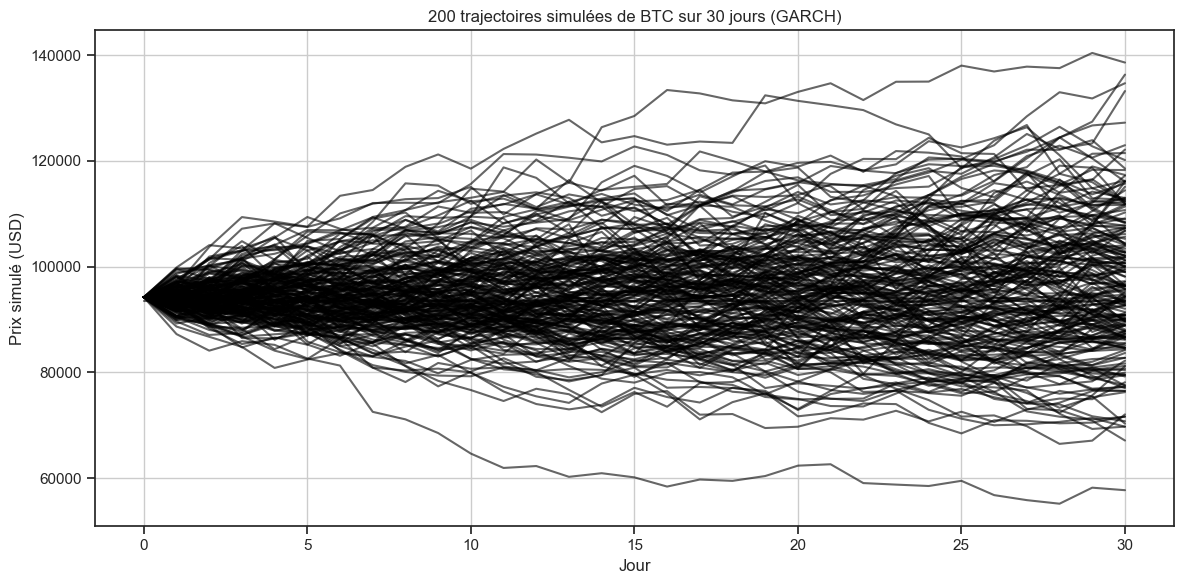

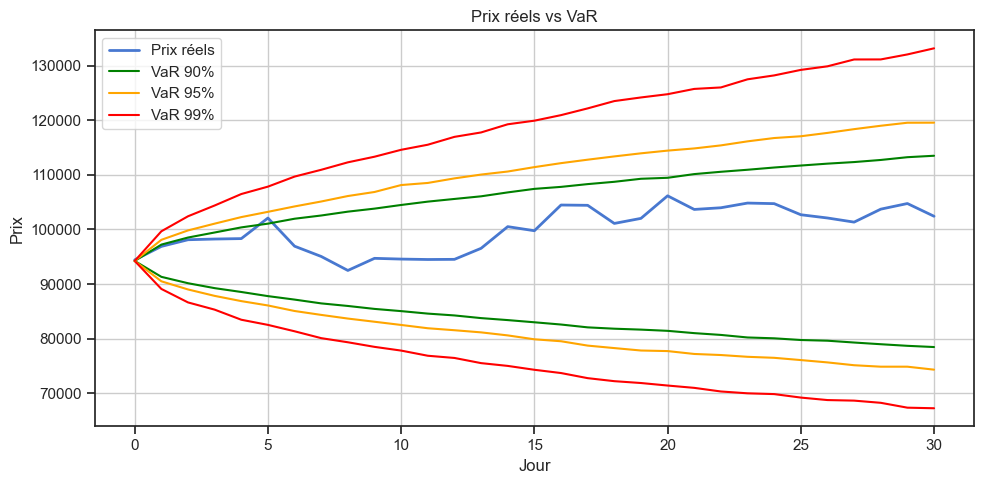

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# Simulate GARCH(1,1)

file_path = "BTC-USD.csv"
forecast_horizon = T    
simulations = N         

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df["Log_Ret"] = np.log(df["Price"] / df["Price"].shift(1))
df.dropna(inplace=True)

returns = df["Log_Ret"]["2024-01-01":"2024-12-31"].copy() * 100 
model = arch_model(returns, vol="Garch", p=1, q=1)
fit = model.fit(disp="off")


params = fit.params
omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

last_vol = fit.conditional_volatility.iloc[-1]
last_return = returns.iloc[-1]

sim_logrets = np.zeros((forecast_horizon, simulations))
sim_prices = np.zeros((forecast_horizon, simulations))

# last price observed
last_price = df.loc["2024-12-31", "Price"]

for i in range(simulations):
    sim_prices[:, 0] = last_price
    sigma2 = last_vol ** 2
    r = last_return
    path = [r]  

    for t in range(1, forecast_horizon):
        z = np.random.normal()
        sigma2 = omega + alpha * (r**2) + beta * sigma2
        sigma = np.sqrt(sigma2)
        r = sigma * z
        path.append(r)
    
    sim_logrets[:, i] = np.array(path) / 100  
    sim_prices[:, i] = last_price * np.exp(np.cumsum(sim_logrets[:, i]))


plt.figure(figsize=(12, 6))
for i in range(200):
    plt.plot(sim_prices[:, i], alpha=0.6, color="black")
plt.title(f"200 trajectoires simulées de BTC sur {forecast_horizon-1} jours (GARCH)")
plt.xlabel("Jour")
plt.ylabel("Prix simulé (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

days = np.arange(forecast_horizon)


var_90b = np.percentile(sim_prices, 10, axis=1)  
var_90h = np.percentile(sim_prices, 90, axis=1)  
var_95b = np.percentile(sim_prices, 5, axis=1) 
var_95h = np.percentile(sim_prices, 95, axis=1)
var_99b = np.percentile(sim_prices, 1, axis=1)   
var_99h = np.percentile(sim_prices, 99, axis=1)


mean_prediction = np.mean(sim_prices, axis=1)


real_prices = df["Price"].loc["2025-01-01":].values[:forecast_horizon]  


plt.figure(figsize=(10, 5))
plt.plot(real_prices, label="Prix réels", linewidth=2)
plt.plot(var_90b, label="VaR 90%", color="green")
plt.plot(var_95b, label="VaR 95%", color="orange")
plt.plot(var_99b, label="VaR 99%", color="red")
plt.plot(var_90h, color="green")
plt.plot(var_95h, color="orange")
plt.plot(var_99h, color="red")

plt.title("Prix réels vs VaR")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





Step 10: Calculating Mean Absolute Error (MAE)...
Step 11: Plotting historical and simulated volatility...
pourcentage d'indices où Log-Ret < volatilité estimée : 0.16129032258064516


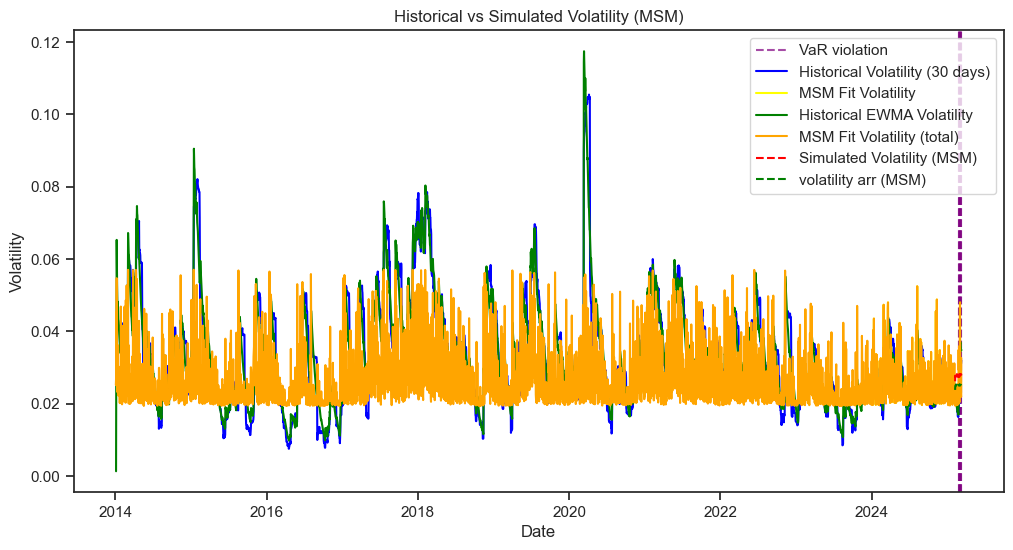

Step 12: Mean Absolute Error (MAE) between Historical Volatility and Simulated Volatility: 0.006783474257659487


In [16]:
# Calculate MAE between simulated volatility and historical volatility

print("Step 10: Calculating Mean Absolute Error (MAE)...")
mae = calculate_mae(historical_vol[-T:].values, simulation_vol)


print("Step 11: Plotting historical and simulated volatility...")
plt.figure(figsize=(12, 6))

var_threshold = simulation_vol * stats.norm.ppf(0.10)
logret_recent = df['Log_Ret'].iloc[-T:]
var_series = pd.Series(var_threshold, index=logret_recent.index)
indices_below = logret_recent[logret_recent < var_series].index

for date in indices_below:
    plt.axvline(x=date, color='purple', linestyle='--', alpha=0.7, label="VaR violation" if date == indices_below[0] else "")

print(f"pourcentage d'indices où Log-Ret < volatilité estimée : {len(indices_below)/T}")

plt.plot(historical_vol.index, historical_vol, label="Historical Volatility (30 days)", color='blue')
plt.plot(df_train.index, msm_fit_volatility, label="MSM Fit Volatility", color='yellow')
plt.plot(ewma_vol.index, ewma_vol, label="Historical EWMA Volatility", color='green')
plt.plot(df.index, msm_fit_volatility_tot, label="MSM Fit Volatility (total)", color='orange')

plt.plot(historical_vol.index[-T:], simulation_vol, label="Simulated Volatility (MSM)", color='red', linestyle='--')
plt.plot(historical_vol.index[-T:], volatilite_arr, label="volatility arr (MSM)", color='green', linestyle='--')



plt.title('Historical vs Simulated Volatility (MSM)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend(loc="best")
plt.savefig("outofsample")
plt.show()

print(f"Step 12: Mean Absolute Error (MAE) between Historical Volatility and Simulated Volatility: {mae}")